In [174]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
#plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

#from public_tests import * 

from autils import *
#from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

In [175]:
df = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/final/nba_ml_dataset.csv")
baseline_ref = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/2024_espn_predicted_wins.csv")



In [176]:
target = "reg_season_wins"
ignore_cols = ["season","team","reg_season_wins","reg_losses","team_avg_bpm","team_avg_per","team_max_usg","team_players_qualified","team_total_vorp","team_total_ws","team_usg_gini"]
feature_cols = [c for c in df.columns if c not in ignore_cols]
feature_cols = [
    c for c in feature_cols
    if df[c].dtype != "object"
]

In [177]:
print(feature_cols)

['split', 'p1_height_cm', 'p1_weight_kg', 'p1_age', 'p1_assistPercent', 'p1_assists', 'p1_blockPercent', 'p1_blocks', 'p1_box', 'p1_defensiveBox', 'p1_defensiveRBPercent', 'p1_defensiveRb', 'p1_defensiveWS', 'p1_effectFgPercent', 'p1_fieldAttempts', 'p1_fieldGoals', 'p1_fieldPercent', 'p1_ft', 'p1_ftAttempts', 'p1_ftPercent', 'p1_ftr', 'p1_games', 'p1_gamesStarted', 'p1_minutesPg', 'p1_minutesPlayed', 'p1_offensiveBox', 'p1_offensiveRBPercent', 'p1_offensiveRb', 'p1_offensiveWS', 'p1_per', 'p1_personalFouls', 'p1_points', 'p1_position', 'p1_stealPercent', 'p1_steals', 'p1_threeAttempts', 'p1_threeFg', 'p1_threePAR', 'p1_threePercent', 'p1_totalRBPercent', 'p1_totalRb', 'p1_tsPercent', 'p1_turnoverPercent', 'p1_turnovers', 'p1_twoAttempts', 'p1_twoFg', 'p1_twoPercent', 'p1_usagePercent', 'p1_vorp', 'p1_winShares', 'p1_winSharesPer', 'p2_height_cm', 'p2_weight_kg', 'p2_age', 'p2_assistPercent', 'p2_assists', 'p2_blockPercent', 'p2_blocks', 'p2_box', 'p2_defensiveBox', 'p2_defensiveRBPerc

In [178]:
#Split dataset
train_df = df[(df["season"] >= 2017) & (df["season"] <= 2025)]
val_df = df[(df["season"] >= 2015) & (df["season"] <= 2017)]
test_df = df[(df["season"] >= 2003) & (df["season"] <= 2009)]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [179]:
#Fill missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [180]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [181]:
X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [182]:
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [   
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.002)),
        #Dropout(0.3),
        Dense(128, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(64, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(1)
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [183]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "mse", 
    metrics = ["mae"]
)
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 256)            │       128,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,729 (663.00 KB)

 Trainable params: 169,729 (663.00 KB)

 Non-trainable params: 0 (0.00 B)

In [184]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # watch validation loss
    patience=10,              # stop after 10 epochs without improvement
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1, 
    callbacks=[early_stop]
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1521.2903 - mae: 37.1334 - val_loss: 1282.5095 - val_mae: 33.7434
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 813.9320 - mae: 26.3650 - val_loss: 377.2667 - val_mae: 17.4077
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 188.9914 - mae: 11.3700 - val_loss: 175.9379 - val_mae: 10.3729
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 156.2489 - mae: 9.1388 - val_loss: 103.3563 - val_mae: 8.1672
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 57.8807 - mae: 6.1262 - val_loss: 102.9208 - val_mae: 8.1804
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.2948 - mae: 4.1688 - val_loss: 67.7497 - val_mae: 6.7051
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.5232 - mae: 3.5090 - val_loss: 62.5319 - val_mae: 6.1174
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.7676 - mae: 2.8039 - val_loss: 63.3988 - val_mae: 5.9639
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/st

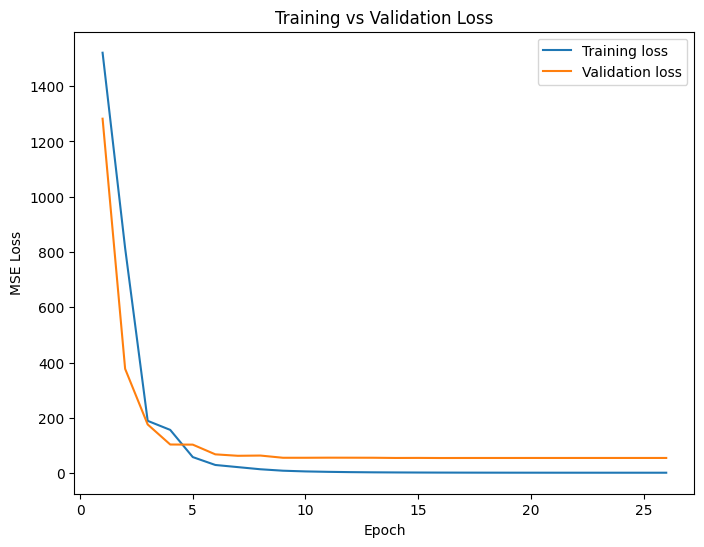

In [185]:
#Plot training vs validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs_range, train_loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [186]:
# Predictions
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [187]:
# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
test_r2 = r2_score(y_test, test_preds)

train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("\nTrain Results: ")
print("RMSE:", train_rmse)
print("R2 Score:", train_r2)
print("MAE:", train_mae)

print("\nValidation Results: ")
print("RMSE:", val_rmse)
print("R2 Score:", val_r2)
print("MAE:", val_mae)


print("\nTest Results:")
print("RMSE:", test_rmse)
print("R2 Score:", val_r2)
print("MAE:", test_mae)


Train Results: 
RMSE: 0.6047920136730509
R2 Score: 0.9973660111427307
MAE: 0.43453699350357056

Validation Results: 
RMSE: 7.296096531513818
R2 Score: 0.668903112411499
MAE: 5.103972911834717

Test Results:
RMSE: 9.485840534939268
R2 Score: 0.668903112411499
MAE: 7.482563495635986


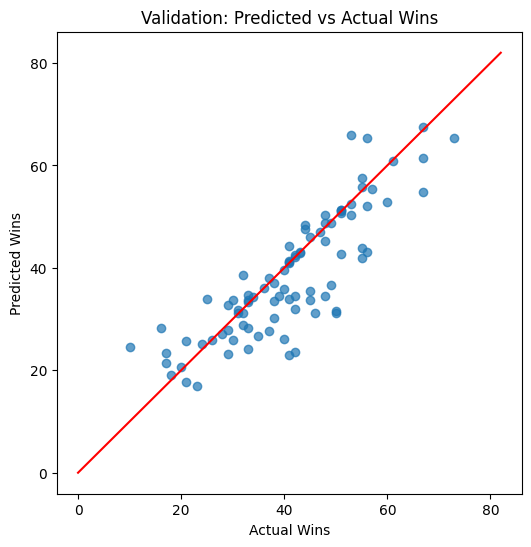

In [188]:
# Validation precdiction graph
plt.figure(figsize=(6,6))

plt.scatter(y_val, val_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Validation: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

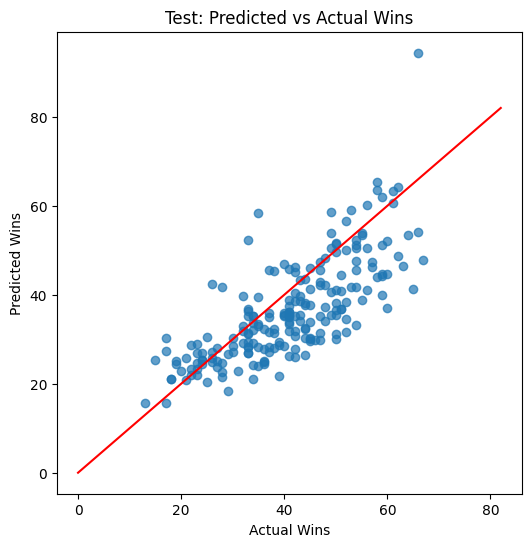

In [189]:
#Test Prediction Graph
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Test: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

In [190]:
predictions = pd.DataFrame({
    "Actual Wins": y_test, 
    "Predicted Wins": test_preds.flatten()
})
print("\nSample Predictions")
print(predictions.head())


Sample Predictions
   Actual Wins  Predicted Wins
0         35.0       33.073448
1         44.0       38.074734
2         30.0       28.435144
3         17.0       27.303249
4         60.0       52.039093


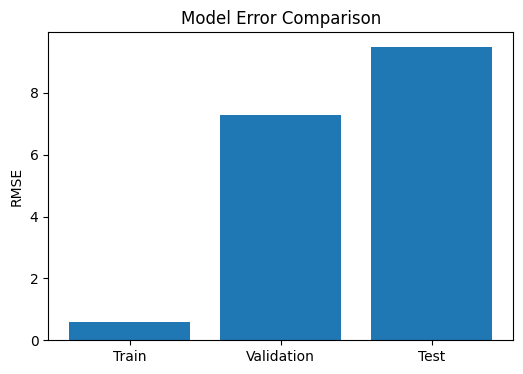

In [191]:
labels = ["Train", "Validation", "Test"]
errors = [train_rmse, val_rmse, test_rmse]

plt.figure(figsize=(6,4))

plt.bar(labels, errors)

plt.ylabel("RMSE")
plt.title("Model Error Comparison")

plt.show()


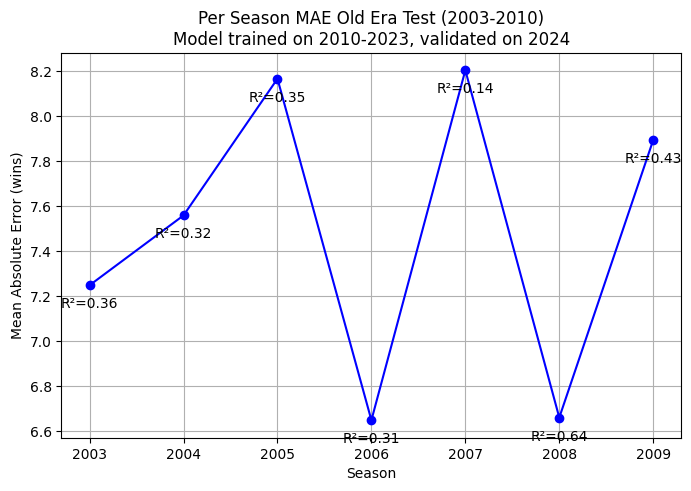

In [192]:
from sklearn.metrics import mean_absolute_error

# Build dataframe with predictions and seasons
test_results = test_df.copy()
test_results["pred_wins"] = test_preds.flatten()

# Compute MAE and R2 per season
season_stats = []

for season, group in test_results.groupby("season"):
    
    mae = mean_absolute_error(group[target], group["pred_wins"])
    r2 = r2_score(group[target], group["pred_wins"])
    
    season_stats.append({
        "season": season,
        "mae": mae,
        "r2": r2
    })

season_stats = pd.DataFrame(season_stats).sort_values("season")

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    season_stats["season"],
    season_stats["mae"],
    color="blue",
    marker="o"
)

# Label each point with R^2
for i, row in season_stats.iterrows():
    plt.text(
        row["season"],
        row["mae"] - 0.1,
        f"R²={row['r2']:.2f}",
        ha="center"
    )

plt.xlabel("Season")
plt.ylabel("Mean Absolute Error (wins)")
plt.title("Per Season MAE Old Era Test (2003-2010)\nModel trained on 2010-2023, validated on 2024")

plt.xticks(range(2003, 2010))
plt.grid(True)

plt.show()



In [193]:
test_results = test_df.copy()
test_results["actual"] = y_test
test_results["predicted"] = test_preds.flatten()

season_stats = test_results.groupby("season").apply(
    lambda g: pd.Series({
        "mae": mean_absolute_error(g["actual"], g["predicted"]),
        "r2": r2_score(g["actual"], g["predicted"])
    })
).reset_index().sort_values("season")
overall_mae = season_stats["mae"].mean()

/var/folders/q3/tstfht8j1275120nd9n60bhm0000gn/T/ipykernel_20152/320130830.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  season_stats = test_results.groupby("season").apply(


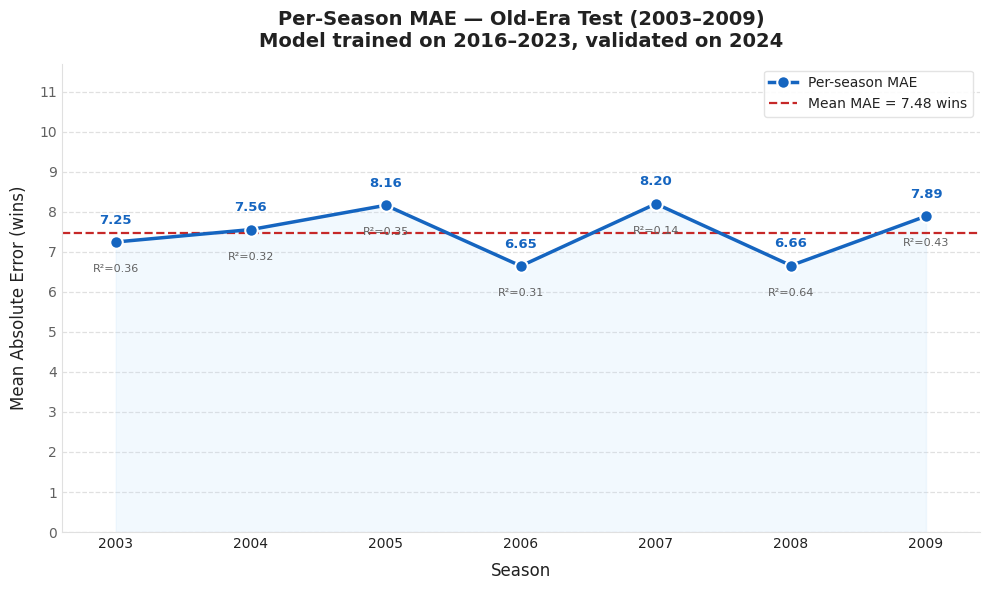

  Saved: report_old_era_mae_by_season.png


In [194]:
# ── Line chart ────────────────────────────────────────────────────────────────
seasons  = season_stats["season"].astype(int).tolist()
mae_vals = season_stats["mae"].tolist()
r2_vals  = season_stats["r2"].tolist()

# Colour constants — white background, readable
LINE_C   = "#1565C0"   # blue line / markers
FILL_C   = "#BBDEFB"   # light-blue fill under curve
AVG_C    = "#C62828"   # red dashed average line
GRID_C   = "#E0E0E0"
TEXT_C   = "#212121"
SUB_C    = "#616161"

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Shaded area under the MAE curve
ax.fill_between(seasons, mae_vals, alpha=0.18, color=FILL_C, zorder=1)

# MAE line + markers
ax.plot(seasons, mae_vals,
        color=LINE_C, linewidth=2.5, marker="o",
        markersize=9, markerfacecolor=LINE_C,
        markeredgecolor="white", markeredgewidth=1.5,
        zorder=3, label="Per-season MAE")

# Annotate each point: MAE value above, R² below
for sx, my, ry in zip(seasons, mae_vals, r2_vals):
    ax.annotate(f"{my:.2f}",
                xy=(sx, my), xytext=(0, 11),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=9.5, fontweight="bold", color=LINE_C)
    ax.annotate(f"R²={ry:.2f}",
                xy=(sx, my), xytext=(0, -16),
                textcoords="offset points",
                ha="center", va="top",
                fontsize=8, color=SUB_C)

# Overall-average reference line
ax.axhline(overall_mae, color=AVG_C, linewidth=1.6,
           linestyle="--", zorder=2,
           label=f"Mean MAE = {overall_mae:.2f} wins")

# Grid + spines
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=GRID_C, linewidth=0.9, linestyle="--")
ax.xaxis.grid(False)
for side, spine in ax.spines.items():
    spine.set_visible(side in ("bottom", "left"))
    if side in ("bottom", "left"):
        spine.set_color(GRID_C)

ax.tick_params(axis="both", length=0, labelcolor=TEXT_C)
ax.set_xticks(seasons)
ax.set_xticklabels([str(s) for s in seasons], fontsize=10, color=TEXT_C)
ax.set_yticks(np.arange(0, max(mae_vals) + 3, 1))
ax.yaxis.set_tick_params(labelsize=10, labelcolor=SUB_C)

# Y-axis lower bound: always 0 so the scale isn't misleadingly zoomed
ax.set_ylim(0, max(mae_vals) + 3.5)
ax.set_xlim(min(seasons) - 0.4, max(seasons) + 0.4)

ax.set_xlabel("Season", fontsize=12, color=TEXT_C, labelpad=8)
ax.set_ylabel("Mean Absolute Error (wins)", fontsize=12, color=TEXT_C, labelpad=8)
ax.set_title("Per-Season MAE — Old-Era Test (2003–2009)\n"
             "Model trained on 2016–2023, validated on 2024",
             fontsize=14, fontweight="bold", color=TEXT_C, pad=12)

ax.legend(loc="upper right", frameon=True, framealpha=0.9,
          facecolor="white", edgecolor=GRID_C,
          labelcolor=TEXT_C, fontsize=10)

plt.tight_layout()
plt.savefig("report_old_era_mae_by_season.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()
print("  Saved: report_old_era_mae_by_season.png")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


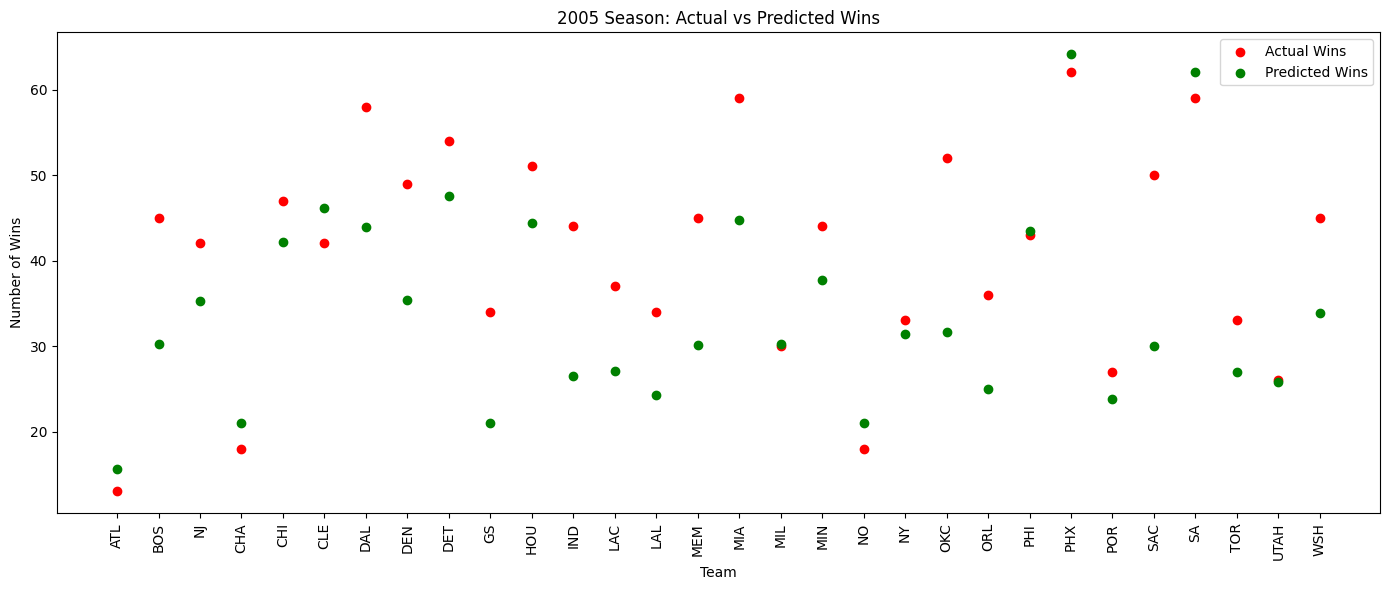